In [183]:
import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}

import os

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [ ]:
url='https://virtualwall.org/iAlpha.htm'
html=requests.get(url, headers=headers).content
soup=BeautifulSoup(html)

alphabet_urls=['https://virtualwall.org/'+e['href'] for e in soup.select('table[class="x"] x x')]

all_casualties_urls=[]
for i, alphabet_url in enumerate(alphabet_urls,start=1):
    html=requests.get(alphabet_url, headers=headers).content
    soup=BeautifulSoup(html)

    casualty_urls=[alphabet_url.split('0')[0]+e['href'] for e in soup.select('tr td a')]
    all_casualties_urls.extend(casualty_urls)

    print(f'{i}/{len(alphabet_urls)}',end='\r')


In [ ]:
all_casualties_urls=[e for e in all_casualties_urls if '/../' not in e]
all_casualties_urls=sorted(all_casualties_urls)
len(all_casualties_urls)

pickle.dump(all_casualties_urls, open(f'VietnamCasualtiesURLs.pickle','wb'))

In [ ]:
all_casualties_urls=pickle.load( open(f'VietnamCasualtiesURLs.pickle','rb'))
len(all_casualties_urls)

In [ ]:
max_index = 0

for file in os.listdir('Vietnam'):
    if file.startswith('VietnamCasualties'):
        index = int(file.split('_')[-1].split('.')[0])
        if index > max_index:
            max_index = index

print(max_index)

In [ ]:
all_data=[]

for i, casualty_url in enumerate(all_casualties_urls,start=1):
    if i<=max_index:
        continue
    try:
        html=requests.get(casualty_url, headers=headers).content
        soup=BeautifulSoup(html)
    except:
        all_data.append({'URL':None})
        continue

    try:
        name=soup.select_one('div[class="x"]').text
    except:
        name=None
    try:
        info=soup.select_one('table div[class="x"]').text
    except:
        info=None
    try:
        medals=[e['title'] for e in soup.select('table[class="x"] img')]
    except:
        medals=None

    info_dict={'URL':casualty_url, 'Name':name, 'Info':info,'Medals':medals}
    all_data.append(info_dict)

    print(f'{i}/{len(all_casualties_urls)}',end='\r')

    if i%1000==0 or i==len(all_casualties_urls):
        pickle.dump(all_data, open(f'Vietnam/VietnamCasualties_{i}.pickle','wb'))
        all_data=[]

In [ ]:
all_data=[]
for file in os.listdir('Vietnam'):
    data=pickle.load(open(os.path.join('Vietnam',file),'rb'))
    all_data.extend(data)

In [162]:
#pickle.dump(all_data, open('all_vietnam_data.pickle','wb'))
all_data=pickle.load( open('all_vietnam_data.pickle','rb'))

In [163]:
df=pd.DataFrame(all_data)

### info

In [164]:
url_info_dict={}
for i, row in df.iterrows():
    info=row['Info'].split('\n')
    url=row['URL']

    if len(info)==8:
        info=[i for i in info if i!='']
        dict_={
        "rank": info[0],
        "unit": None,
        "branch": info[1],
        "home": info[2],
        "birth_death": info[3],
        "incident_date": None,
        "memorial_location": info[4]}
        url_info_dict[url]=dict_
        
    elif len(info)==9:
        info=[i for i in info if i!='']
        dict_={
        "rank": info[0],
        "unit": info[1],
        "branch": info[2],
        "home": info[3],
        "birth_death": info[4],
        "incident_date": None,
        "memorial_location": info[5]}
        url_info_dict[url]=dict_
        
    elif len(info)==10:
        info=[i for i in info if i!='']
        dict_={
        "rank": info[0],
        "unit": info[1],
        "branch": info[2],
        "home": info[3],
        "birth_death": info[4],
        "incident_date": info[5],
        "memorial_location": info[6]}
        url_info_dict[url]=dict_
        
    elif len(info)==11:
        info=[i for i in info if i!='']
        dict_={
        "rank": info[0],
        "unit": info[1],
        "branch": info[2],
        "home": info[3],
        "birth_death": info[5],
        "incident_date": info[6],
        "memorial_location": info[7]}
        url_info_dict[url]=dict_

    else:
        url_info_dict[url]=None

    print(i, end='\r')
        
    

58274

In [165]:
df['Info']=df['URL'].map(url_info_dict)

In [166]:
df_expanded = pd.json_normalize(df['Info'])

In [167]:
df=pd.concat([df, df_expanded], axis=1)

In [168]:
df=df.drop(columns='Info')

### medals

In [169]:
new_medals = []

for medal_list in df['Medals']:
    filtered = []
    for medal in medal_list:
        if 'awarded' in medal or medal.startswith('Distinguished'):
            filtered.append(medal)
    if not filtered:
        filtered = None
    new_medals.append(filtered)

df['Medals'] = new_medals

In [170]:
df['Medals'].iloc[1500]

['SSG Tadios was awarded: POW Medal',
 'SSG Tadios was awarded: Bronze Star (valor), Purple Heart, National Defense, Vietnam Service, and Vietnam Campaign medals']

In [171]:
all_medals = []

for medal_lists in df['Medals']:
    combined_medals = []
    if medal_lists is not None:
        for medal_list in medal_lists:
            if medal_list:
                medals = [m.strip() for m in medal_list.split('awarded:')[-1].replace(' and',',').split(',')]
                combined_medals.extend(medals)
    all_medals.append(combined_medals)

df['Medals']=all_medals

In [ ]:
all_medals=[]
for i, medal_list in enumerate(df['Medals']):
    try:
        for medal in medal_list:
            all_medals.append(medal)
    except:
        print(i)

all_kind_medals=set(all_medals)

In [175]:
medal_mapping = {
    # Remove empty or invalid entries
    '': None,
    '1st Class)': None,
    'Air': None,
    'merit)': None,

    # Vietnam Campaign Medal
    'Vietnam Campaign Medals': 'Vietnam Campaign Medal',
    'Vietnam Campaign Medals.': 'Vietnam Campaign Medal',
    'Vietnam Campaign medals': 'Vietnam Campaign Medal',
    'RVN Campaign': 'Vietnam Campaign Medal',

    # Vietnam Service Medal
    'Vietnam Service': 'Vietnam Service Medal',
    'Vietnam Svc': 'Vietnam Service Medal',

    # Army Commendation Medal
    'Army Commendation': 'Army Commendation Medal (Merit)',
    'Army Commendation (merit)': 'Army Commendation Medal (Merit)',
    'Army Commendation (valor)': 'Army Commendation Medal (Valor)',
    'Army Commendation (awards for valor': 'Army Commendation Medal (Valor)',
    'Army Commendation V Device medals': 'Army Commendation Medal (Valor)',
    'Army Commendation medals': 'Army Commendation Medal (Merit)',

    # Bronze Star Medal
    'Bronze Star': 'Bronze Star Medal (Merit)',
    'Bronze Star (3)': 'Bronze Star Medal (Merit)',
    'Bronze Star (awards for valor': 'Bronze Star Medal (Valor)',
    'Bronze Star (merit)': 'Bronze Star Medal (Merit)',
    'Bronze Star (valor)': 'Bronze Star Medal (Valor)',
    'Bronze Star Valor': 'Bronze Star Medal (Valor)',
    '3 Bronze Stars (valor)': 'Bronze Star Medal (Valor)',

    # Good Conduct Medal
    'Army Good Conduct': 'Good Conduct Medal',
    'Good Conduct': 'Good Conduct Medal',

    # POW / Prisoner of War Medal
    'POW Medal': 'Prisoner of War Medal',
    'Prisoner of War Medal': 'Prisoner of War Medal',

    # Air Force
    'Air Force Commendation (merit)': 'Air Force Commendation Medal (Merit)',
    'Air Force Cross': 'Air Force Cross',
    'Air Medal': 'Air Medal',

    # Navy
    'Navy Commendation': 'Navy Commendation Medal (Merit)',
    'Navy Commendation (merit)': 'Navy Commendation Medal (Merit)',
    'Navy Commendation (valor)': 'Navy Commendation Medal (Valor)',
    'Navy Cross': 'Navy Cross',
    'Navy Unit Commendation': 'Navy Unit Commendation',
    'Navy Occupation Service Medal (Europe)': 'Navy Occupation Service Medal (Europe)',

    # USMC
    'USMC Commendation Medals<br>\xa0<br clear=': 'USMC Commendation Medal',
    'Marine Commendation': 'USMC Commendation Medal',

    # Medal of Honor
    'Medal of Honor': 'Medal of Honor',
    'RVN Medal of Honor (First Class)': 'RVN Medal of Honor (First Class)',

    # Silver Star
    'Silver Star Medal': 'Silver Star Medal',

    # Distinguished Crosses
    'Distinguished Flying Cross': 'Distinguished Flying Cross',
    'Distinguished Service Cross': 'Distinguished Service Cross',

    # Legion of Merit
    'Legion of Merit (valor)': 'Legion of Merit (Valor)',

    # Soldiers Medal
    'Soldiers Medal': 'Soldiers Medal',

    # National Defense
    'National Defense': 'National Defense Service Medal',
    'National Defense Service': 'National Defense Service Medal',

    # Korean / UN / WWII
    'Korean Svc': 'Korean Service Medal',
    'RoK Svc': 'Republic of Korea Service Medal',
    'UN Svc': 'United Nations Service Medal',
    'WW2 Occupation': 'WWII Occupation Medal',

    # RVN awards
    'RVN Gallantry Cross': 'Republic of Vietnam Gallantry Cross',
    '2 RVN Cross of Gallantry': 'Republic of Vietnam Gallantry Cross',
    'RVN Meritorious Unit Citation (Civic Actions': 'Republic of Vietnam Meritorious Unit Citation',
    'RVN Wound': 'Republic of Vietnam Wound Medal',

    # Purple Heart
    'Purple Heart': 'Purple Heart',
    '2 Purple Hearts': 'Purple Heart',
}

In [176]:
all_true_medals=[]

for i, medals in enumerate(df['Medals']):
    true_medals=[]
    for medal in medals:
        true_medal=medal_mapping[medal]
        true_medals.append(true_medal)
    true_medals=[i for i in true_medals if i is not None]
    all_true_medals.append(true_medals)

len(all_true_medals)
df['Medals']=all_true_medals      

In [177]:
all_medals=[]
for i, medal_list in enumerate(df['Medals']):
    try:
        for medal in medal_list:
            all_medals.append(medal)
    except:
        print(i)

all_kind_medals=set(all_medals)
print(len(all_kind_medals))
all_kind_medals


33


{'Air Force Commendation Medal (Merit)',
 'Air Force Cross',
 'Air Medal',
 'Army Commendation Medal (Merit)',
 'Army Commendation Medal (Valor)',
 'Bronze Star Medal (Merit)',
 'Bronze Star Medal (Valor)',
 'Distinguished Flying Cross',
 'Distinguished Service Cross',
 'Good Conduct Medal',
 'Korean Service Medal',
 'Legion of Merit (Valor)',
 'Medal of Honor',
 'National Defense Service Medal',
 'Navy Commendation Medal (Merit)',
 'Navy Commendation Medal (Valor)',
 'Navy Cross',
 'Navy Occupation Service Medal (Europe)',
 'Navy Unit Commendation',
 'Prisoner of War Medal',
 'Purple Heart',
 'RVN Medal of Honor (First Class)',
 'Republic of Korea Service Medal',
 'Republic of Vietnam Gallantry Cross',
 'Republic of Vietnam Meritorious Unit Citation',
 'Republic of Vietnam Wound Medal',
 'Silver Star Medal',
 'Soldiers Medal',
 'USMC Commendation Medal',
 'United Nations Service Medal',
 'Vietnam Campaign Medal',
 'Vietnam Service Medal',
 'WWII Occupation Medal'}

# EDA

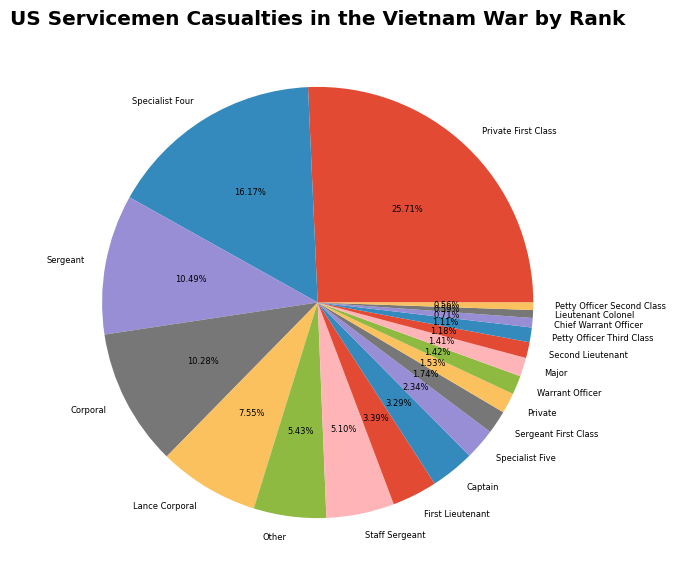

In [216]:
rank_counts = df['rank'].value_counts(normalize=True)
rare_rankes = rank_counts[rank_counts < 0.005].index
df['rank_cleaned'] = df['rank'].replace(rare_rankes, 'Other')
grouped=df['rank_cleaned'].value_counts(normalize=True)

plt.figure(figsize=(7,7))
grouped.plot.pie(fontsize=6, autopct='%.2f%%')
plt.ylabel('')
plt.title("US Servicemen Casualties in the Vietnam War by Rank",fontweight='bold')
plt.show()

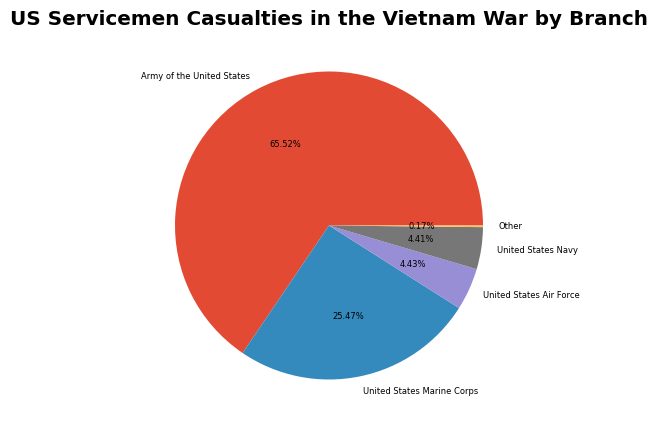

In [217]:
branch_counts = df['branch'].value_counts(normalize=True)
rare_branches = branch_counts[branch_counts < 0.005].index
df['branch_cleaned'] = df['branch'].replace(rare_branches, 'Other')
grouped=df['branch_cleaned'].value_counts(normalize=True)

plt.figure(figsize=(5,5))
grouped.plot.pie(fontsize=6, autopct='%.2f%%')
plt.ylabel('')
plt.title("US Servicemen Casualties in the Vietnam War by Branch",fontweight='bold')
plt.show()

In [225]:
df['state']=df['home'].apply(lambda x:x.split(',')[-1])

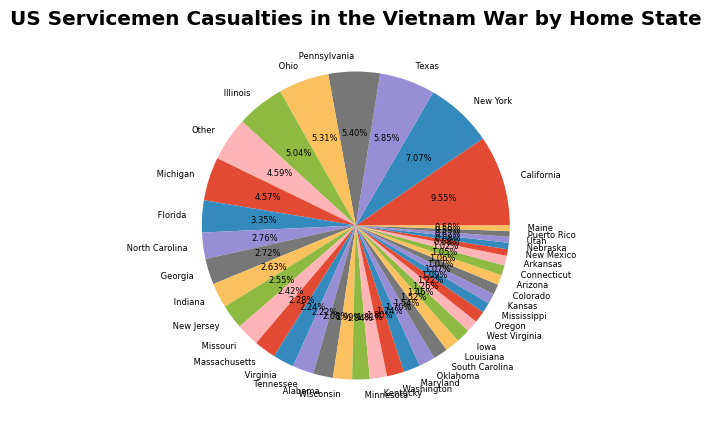

In [227]:
state_counts = df['state'].value_counts(normalize=True)
rare_statees = state_counts[state_counts < 0.005].index
df['state_cleaned'] = df['state'].replace(rare_statees, 'Other')
grouped=df['state_cleaned'].value_counts(normalize=True)

plt.figure(figsize=(5,5))
grouped.plot.pie(fontsize=6, autopct='%.2f%%')
plt.ylabel('')
plt.title("US Servicemen Casualties in the Vietnam War by Home State",fontweight='bold')
plt.show()

In [228]:
df=df.drop(columns='state')

In [281]:
birth=df['birth_death'].apply(lambda x:x.split(' to ')[0])
death=df['birth_death'].apply(lambda x:x.split(' to ')[-1])

birth=pd.to_datetime(birth,errors='coerce')
death=pd.to_datetime(death,errors='coerce')

df['Age']=(death - birth).dt.days / 365
death_age=round(df['Age'].mean(),1)
print(f"The average age at death of U.S. servicemen during the Vietnam War is {death_age} years")


The average age at death of U.S. servicemen during the Vietnam War is 23.3 years


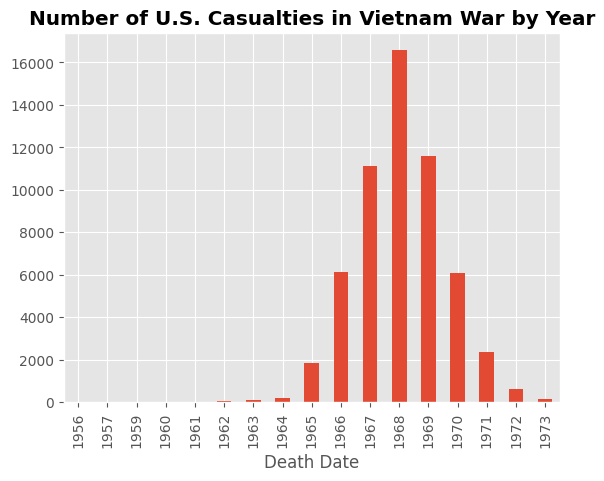

In [291]:
df['Death Date']=death
filtered=df[df['Death Date']<="1974-01-01"]
filtered.groupby(filtered['Death Date'].dt.to_period('Y'))['Name'].count().plot.bar()
plt.title('Number of U.S. Casualties in Vietnam War by Year',fontweight='bold')
plt.show()

In [306]:
all_medals=[]
for medals in df['Medals']:
    all_medals.extend(medals)

print('Number of medals issued')
pd.Series(all_medals).value_counts()

Number of medals issued


National Defense Service Medal                   58260
Vietnam Campaign Medal                           58260
Vietnam Service Medal                            58260
Purple Heart                                     47739
Air Medal                                         7633
Good Conduct Medal                                5000
Bronze Star Medal (Merit)                         2938
Bronze Star Medal (Valor)                         2105
Silver Star Medal                                 1757
Distinguished Flying Cross                         477
Distinguished Service Cross                        294
Army Commendation Medal (Merit)                    193
Navy Cross                                         112
Medal of Honor                                     111
Prisoner of War Medal                              110
Air Force Cross                                     46
Army Commendation Medal (Valor)                     38
Air Force Commendation Medal (Merit)                15
Navy Comme